In [1]:
import numpy as np 
from gaussrnd import *
import matplotlib.pyplot as plt
from forwardmodel import *
import time
from helper import *
np.random.seed(1)

# specify the prior:
alpha=2
tau=5 
scale=10
# level sets for wave speed: # the numbers are approximate 
c_high = np.exp(0.27)
c_low  = np.exp(-0.27)

thresh_1= 0.14 # this is roughly 0.4*std
thresh_2=-0.14
# solver adjustment:

N = 100 # number of spatial intervals
dt = 2e-4
L=1
f0=20
dx=L/N
xs_frac=0.5
T=1
Np1= N+1 # number of grid points including the boundary
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N  # shape (N,) x at the center points
i = np.arange(0, Np1 )
x_nodes = i*dx
Lmat = build_L_neumann_matrix(Np1, dx) # solver setting (call once)
# observation:
# --- spatial receivers (indices on x grid) ---
Nr = 10
Nrp2 = Nr+2
i = np.arange(0 , Nrp2)
dx_obs=L/(Nr+1)
ratio_obs_to_discritization= int(dx_obs/dx)
x_nodes_rec = i*dx_obs

recv_idx = (i*ratio_obs_to_discritization)[1:-1]
x_recv = x_nodes[recv_idx]
print(recv_idx)
# --- time samples (indices on t grid) ---
dt_obs = dt                     
time_idx = np.arange(0, int(T/dt_obs)) * int(dt_obs/dt)
t_recv = time_idx * dt


Ny = len(time_idx) * len(recv_idx)


# sampling:
Nsample=100
U_samples_center = np.zeros((N, Nsample))
Arrival_store=np.zeros((Nr,Nsample))
for i in range(Nsample):
    U_samples_center[:, i] = gaussrnd(alpha, tau, N, scale=scale)
    # interpolate to get u at the nodes
    U_sample = np.interp(x_nodes, x_center, U_samples_center[:, i])
    
    c = levelset_to_c_binary(
        U_sample,
        c_high=c_high,
        c_low=c_low)
    # solve the PDE
    # t1=time.time()
    x, t, P = solve_wave_1d(c=c, Lmat=Lmat, L=L, T=T, f0=f0, xs_frac=xs_frac, dt=dt)
    # t2=time.time()
    # print(t2-t1)
    Y,y=observe_from_grid(P, time_idx, recv_idx) # I dont want to add noise to the data anymore, I will add it later, during the training.
    # y = y + scale_obs_noise * np.random.randn(y.size)
    ArrivalTimes=extract_arrival_times(Y, t_recv) # extracting the arrival times. 
    Arrival_store[:, i] = ArrivalTimes


[ 9 18 27 36 45 54 63 72 81 90]


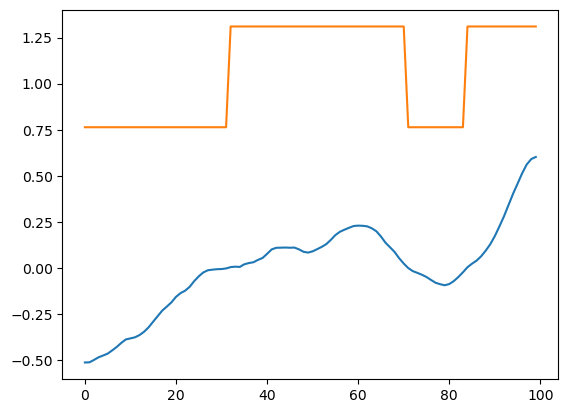

In [54]:
plt.plot(U_samples_center[:,0])
plt.plot(levelset_to_c_binary(
        U_samples_center[:,0],
        c_high=c_high,
        c_low=c_low))

In [47]:
mean_positive = U_samples_center[U_samples_center > 0].mean()
print(mean_positive)

0.25962283079286286


In [48]:
mean_positive = U_samples_center[U_samples_center < 0].mean()
print(mean_positive)

-0.2739218276388324


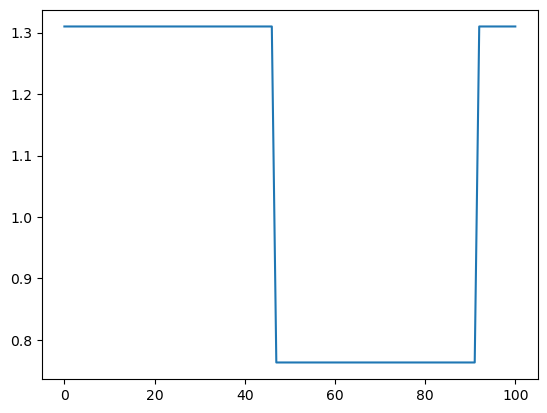

In [49]:
plt.plot(c)

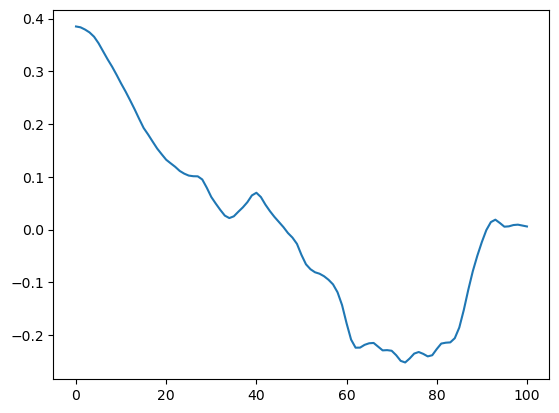

In [50]:
plt.plot(U_sample)

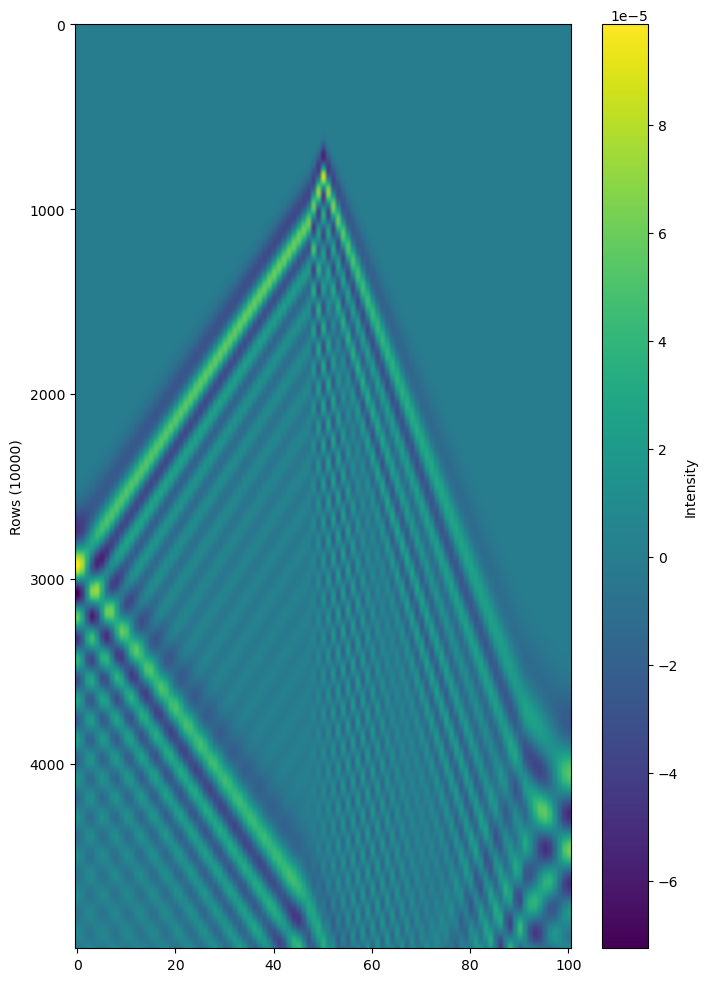

In [51]:
plt.figure(figsize=(8, 12))  # Adjust figure size for better visibility
plt.imshow(P, aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')

plt.ylabel("Rows (10000)")
plt.show()

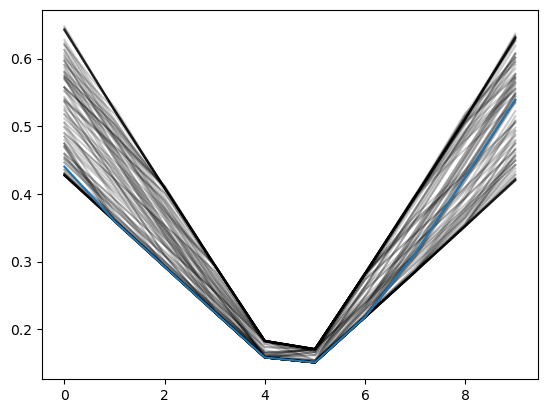

In [52]:
for i in range(Nsample):
    plt.plot(Arrival_store[:,i],color='black',alpha=0.2)
plt.plot(Arrival_store[:,0])


In [9]:
U_samples_center.shape

(100, 10)

In [10]:
mean=np.mean((U_samples_center),axis=1)
std=np.std((U_samples_center),axis=1)

In [11]:
np.mean(mean)

np.float64(-2.7755575615628915e-18)

In [57]:
# to get 

In [2]:
data=np.load("./../../../Data/Experiment7/samples_wave_center.npz")


In [3]:
arrival=data["arrival"]

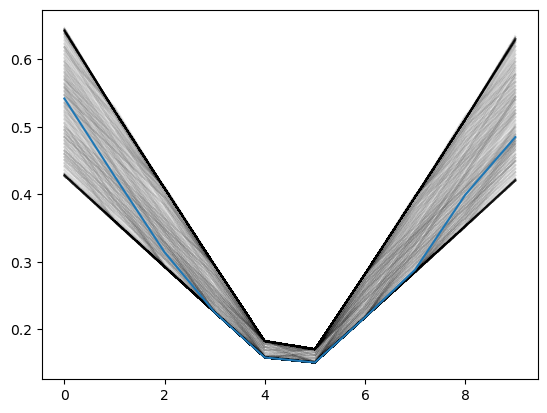

In [4]:
for i in range(1200):
    plt.plot(arrival[:,i],color='black',alpha=0.01)
plt.plot(arrival[:,0])

In [5]:
U=data["U"]

In [6]:
U.shape

(100, 2000000)

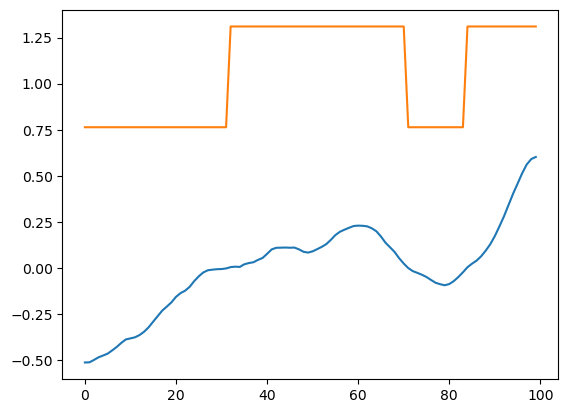

In [7]:
index=0
plt.plot(U[:,index])
plt.plot( levelset_to_c_binary(
        U[:,index],
        c_high=c_high,
        c_low=c_low))